In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# Generazione dati: 10 anni di letture per vari sensori
data_storica = {
    'anno': [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020] * 3,
    'id_sensore': (['S01'] * 10) + (['S02'] * 10) + (['S03'] * 10),
    'tipo_sensore': (['P'] * 20) + (['C'] * 10),
    'lettura_valore': [
        105, 110, 108, 115, 120, 118, 125, 130, 128, 135, # S01 (Crescita costante)
        90, 85, 95, 80, 100, 90, 110, 85, 105, 95,        # S02 (Altalenante)
        50, 52, 48, 55, 60, 58, 62, 65, 63, 68            # S03 (Chimico)
    ]
}

engine = create_engine('sqlite://')
pd.DataFrame(data_storica).to_sql('monitoraggio_storico', engine, index=False)

print("Database Progetto D pronto: tabella 'monitoraggio_storico' caricata.")

Database Progetto D pronto: tabella 'monitoraggio_storico' caricata.


In [29]:
# Mostra la tabella 
df_storico = pd.DataFrame(data_storica)

# Creiamo il motore SQL in memoria (senza password!)
engine = create_engine('sqlite://')
df_storico.to_sql('monitoraggio_storico', engine, index=False)

print("Dataset 'monitoraggio_storico' caricato con successo!")
df_storico.head(10)

Dataset 'monitoraggio_storico' caricato con successo!


,anno,id_sensore,tipo_sensore,lettura_valore
0,2011,S01,P,105
1,2012,S01,P,110
2,2013,S01,P,108
3,2014,S01,P,115
4,2015,S01,P,120
5,2016,S01,P,118
6,2017,S01,P,125
7,2018,S01,P,130
8,2019,S01,P,128
9,2020,S01,P,135


In [30]:
#Ecco le sfide che affronteremo in questo laboratorio:
# 1 - Classificazione con CASE: Crea una colonna che etichetti i sensori come 'Alta Intensità' (>110), 'Media' (50-110) o 'Bassa' (<50).
# 2 - Ranking (RANK): Classifica i sensori in base alla lettura più alta mai registrata.
# 3 - Somma Progressiva (SUM() OVER): Questa è la più affascinante. Calcola per ogni sensore il volume cumulativo prelevato anno dopo anno.

In [31]:
query_geologica_1 = """SELECT 
    id_sensore, 
    lettura_valore, -- Corretto il nome colonna
    CASE
        WHEN lettura_valore > 110 THEN 'Alta Intensita'
        WHEN lettura_valore > 50 THEN 'Media Intensita' -- Semplificato (SQL legge in ordine)
        ELSE 'Bassa Intensita'
    END AS Intensita_Segnale
FROM monitoraggio_storico
LIMIT 5;
"""

query_geologica_2 = """SELECT 
    id_sensore, 
    lettura_valore,
    RANK() OVER (ORDER BY lettura_valore DESC) AS Posizione_Rank -- Corretto nome colonna
FROM monitoraggio_storico
LIMIT 5;
"""

query_geologica_3 = """SELECT 
    anno,
    id_sensore,
    tipo_sensore,
    lettura_valore,
    SUM(lettura_valore) OVER(PARTITION BY id_sensore ORDER BY anno) AS volume_cumulativo
FROM monitoraggio_storico
ORDER BY id_sensore, anno;
"""

# Esecuzione 
risultato_1 = pd.read_sql_query(query_geologica_1, engine)
print("Classificazione dei sensori:")
display(risultato_1)

risultato_2 = pd.read_sql_query(query_geologica_2, engine)
print("Ranking dei sensori:")
display(risultato_2)

risultato_3 = pd.read_sql_query(query_geologica_3, engine)
print("Volume cumulativo negli anni:")
display(risultato_3)

Classificazione dei sensori:


,id_sensore,lettura_valore,Intensita_Segnale
0,S01,105,Media Intensita
1,S01,110,Media Intensita
2,S01,108,Media Intensita
3,S01,115,Alta Intensita
4,S01,120,Alta Intensita


Ranking dei sensori:


,id_sensore,lettura_valore,Posizione_Rank
0,S01,135,1
1,S01,130,2
2,S01,128,3
3,S01,125,4
4,S01,120,5


Volume cumulativo negli anni:


,anno,id_sensore,tipo_sensore,lettura_valore,volume_cumulativo
0,2011,S01,P,105,105
1,2012,S01,P,110,215
2,2013,S01,P,108,323
3,2014,S01,P,115,438
4,2015,S01,P,120,558
5,2016,S01,P,118,676
6,2017,S01,P,125,801
7,2018,S01,P,130,931
8,2019,S01,P,128,1059
9,2020,S01,P,135,1194


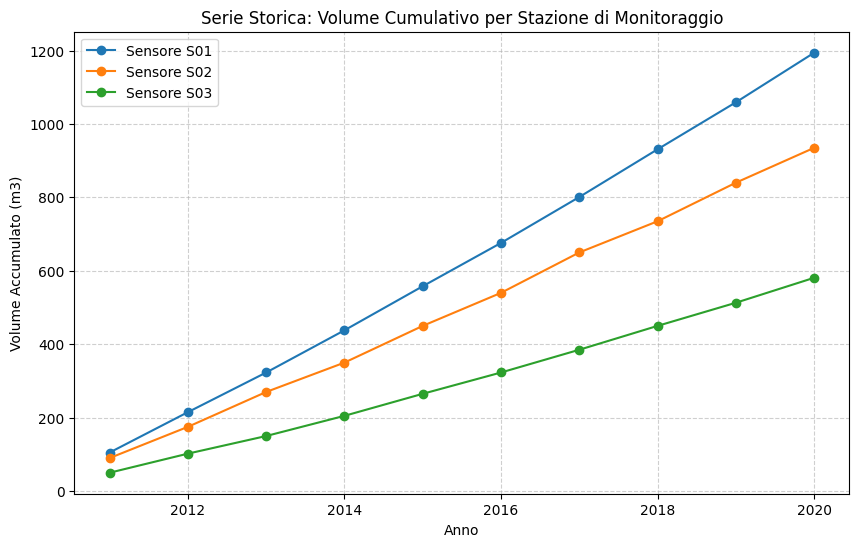

In [32]:
plt.figure(figsize=(10, 6))

# Cicliamo su ogni sensore per disegnare linee diverse
for sensore in risultato_3['id_sensore'].unique():
    # Filtriamo i dati solo per quel sensore
    dati_sensore = risultato_3[risultato_3['id_sensore'] == sensore]
    
    plt.plot(dati_sensore['anno'], dati_sensore['volume_cumulativo'], 
             marker='o', label=f'Sensore {sensore}')

# Personalizzazione
plt.title('Serie Storica: Volume Cumulativo per Stazione di Monitoraggio')
plt.xlabel('Anno')
plt.ylabel('Volume Accumulato (m3)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Analisi Geologica del Grafico
### Sensore S01 (Linea Blu): 
Mostra la pendenza più ripida, confermandosi come il sito con il prelievo cumulativo più alto, superando i 1200 m3 nel 2020.

## Costanza dei Dati: 
La linearità delle tre curve suggerisce un regime di prelievo molto costante nel decennio, senza brusche interruzioni o picchi anomali.

## Confronto: 
Il Sensore S03 (Verde) mantiene il volume più basso, restando sotto i 600 m3 accumulati, coerentemente con la sua natura di sensore "chimico" che avevamo ipotizzato nel setup.